In [ ]:
# Run this cell if using a colab remote kernel and unable to resolve the import `from layoffs.data_loader import load_data`
# uncomment the first line if you have not run on this kernel before
# !git clone https://github.com/sidharthmirch/layoffs.git
!git -C /content/layoffs pull
import sys; sys.path.insert(0, '/content/layoffs')

remote: Enumerating objects: 8, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 5 (delta 2), reused 5 (delta 2), pack-reused 0 (from 0)
Unpacking objects: 100% (5/5), 928 bytes | 25.00 KiB/s, done.
From https://github.com/sidharthmirch/layoffs
   ca13fdf..43deef5  main       -> origin/main
Updating ca13fdf..43deef5
Fast-forward
 classifier.ipynb | 47 ++++-------------------------------------------
 data_loader.py   | 13 +++++++++++++
 explorer.ipynb   | 56 ++++----------------------------------------------------
 3 files changed, 21 insertions(+), 95 deletions(-)
 create mode 100644 data_loader.py


In [5]:
import pandas as pd
from layoffs.data_loader import load_data

train_df, test_df = load_data()

train_df.head()

100%|██████████| 313k/313k [00:00<00:00, 65.0MB/s]

Extracting files...


,company,industry,country,funding_amount,employee_count,growth_rate,valuation,layoff_happened
0,Company_vrzD7Zhl,Real Estate,USA,917215428,53060,143.37,1.706021e+09,0
1,Company_3OJQGaHb,Automotive,Germany,3886088690,98556,177.24,1.869209e+10,0
2,Company_iChfXlEW,Real Estate,Germany,509868992,65992,58.26,3.079609e+09,1
3,Company_GBHyTQ2d,Logistics,UK,4180168950,38180,111.39,2.173688e+10,0
4,Company_cpOLkT6x,Tech,Japan,3031189942,56530,174.79,2.667447e+10,1


## Preprocessing pipeline

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

target_col = "layoff_happened"

X_train = train_df.drop(columns=[target_col]).copy()
y_train = train_df[target_col].copy()

X_test = test_df.drop(columns=[target_col]).copy()
y_test = test_df[target_col].copy()

# removing string company name as no predictive value
# based on eda potential set with only growth rate as predictor?
drop_cols = ["company"] 
X_train = X_train.drop(columns=drop_cols, errors="ignore")
X_test = X_test.drop(columns=drop_cols, errors="ignore")

# categorical encoding
categorical_cols = ["country", "industry"] 
for c in categorical_cols:
    if c in X_train.columns:
        X_train[c] = X_train[c].astype("category")
        X_test[c] = X_test[c].astype("category")


numeric_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = X_train.select_dtypes(exclude=["number"]).columns.tolist()

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, numeric_cols),
        ("cat", categorical_pipe, categorical_cols),],
    remainder="drop")

In [4]:
feature_col = ["growth_rate"]
# building growth_rate only sets

X_train_gr = train_df[feature_col].copy()
y_train_gr = train_df[target_col].copy()

X_test_gr = test_df[feature_col].copy()
y_test_gr = test_df[target_col].copy()

numeric_cols_gr = ["growth_rate"]
categorical_cols_gr = []

numeric_pipe_gr = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor_gr = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe_gr, numeric_cols_gr)
    ],
    remainder="drop"
)

In [5]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, roc_auc_score
from sklearn.model_selection import cross_validate, StratifiedKFold

dummy_pipeline = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", DummyClassifier(strategy="most_frequent", random_state=123))])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

dummy_scores = cross_validate(
    dummy_pipeline,
    X_train, y_train,
    cv=cv,
    scoring=["accuracy", "f1", "roc_auc"])

print("Dummy CV accuracy:", dummy_scores["test_accuracy"].mean())
print("Dummy CV f1:", dummy_scores["test_f1"].mean())
print("Dummy CV roc_auc:", dummy_scores["test_roc_auc"].mean())

Dummy CV accuracy: 0.6838749999999999
Dummy CV f1: 0.0
Dummy CV roc_auc: 0.5


In [6]:
from plotnine import ggplot, aes, geom_line, geom_point, geom_ribbon, geom_hline, labs, theme_bw, annotate
from sklearn.ensemble import RandomForestClassifier
import numpy as np

rf_pipeline = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=10,
        random_state=123,
        class_weight="balanced",
        n_jobs=-1
    ))])


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

rf_scores = cross_validate(
    rf_pipeline,
    X_train, y_train,
    cv=cv,
    scoring=["accuracy", "f1", "roc_auc"],
    return_train_score=False)

print("RF CV accuracy:", rf_scores["test_accuracy"].mean())
print("RF CV f1:", rf_scores["test_f1"].mean())
print("RF CV roc_auc:", rf_scores["test_roc_auc"].mean())

RF CV accuracy: 0.687125
RF CV f1: 0.33984148618451626
RF CV roc_auc: 0.6210326527585865


## Hyperparameter optimization — n_estimators

In [7]:
# first run was: [10, 25, 50, 100, 150, 200, 300, 500]
# best n was 150
# next run was [50, 75, 100, 125, 150, 175, 200]
# nice range of accuracy and std dev in 100---200
# still, we peak at 150 
n_estimator_values = [120, 130, 140, 150, 160, 170, 180]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

results = []
for n in n_estimator_values:
    rf = RandomForestClassifier(n_estimators=n, random_state=123, class_weight="balanced", n_jobs=-1)
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", rf)])
    cv_results = cross_validate(pipe, X_train, y_train, cv=cv, scoring="accuracy")
    results.append({
        "n_estimators": n,
        "mean_accuracy": cv_results["test_score"].mean(),
        "std_accuracy": cv_results["test_score"].std(),
    })

results_df = pd.DataFrame(results)
best_n = results_df.loc[results_df["mean_accuracy"].idxmax(), "n_estimators"]
print(f"Best n_estimators: {best_n}")
results_df

Best n_estimators: 150


,n_estimators,mean_accuracy,std_accuracy
0,120,0.702625,0.005483
1,130,0.701875,0.005303
2,140,0.702250,0.006042
3,150,0.702625,0.004565
4,160,0.702500,0.004330
5,170,0.702250,0.004465
6,180,0.701625,0.004737


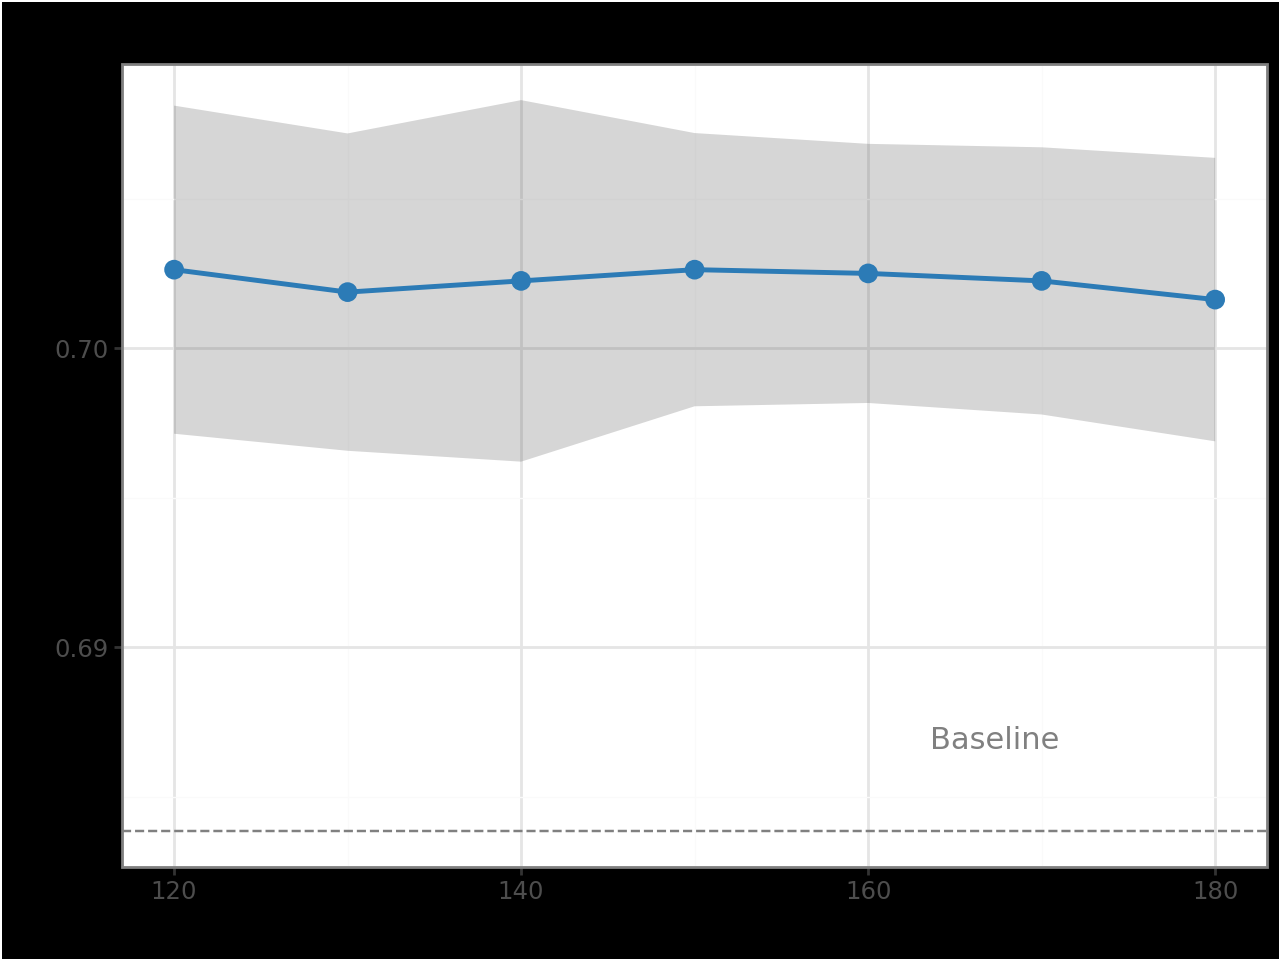

In [8]:
baseline_acc = dummy_scores["test_accuracy"].mean()

(
    ggplot(results_df, aes(x="n_estimators", y="mean_accuracy"))
    + geom_ribbon(aes(ymin="mean_accuracy - std_accuracy", ymax="mean_accuracy + std_accuracy"), alpha=0.2)
    + geom_line(color="#2c7bb6", size=1)
    + geom_point(color="#2c7bb6", size=3)
    + geom_hline(yintercept=baseline_acc, linetype="dashed", color="gray")
    + annotate("text", x=max(n_estimator_values) * 0.95, y=baseline_acc + 0.003, label="Baseline", color="gray", ha="right")
    + labs(title="RF Accuracy vs n_estimators", x="n_estimators", y="Mean CV Accuracy (5-fold)")
    + theme_bw()
)

## Modelling only `growth_rate` as a feature

In [9]:
rf_pipeline_gr = Pipeline(steps=[
    ("prep", preprocessor_gr),
    ("model", RandomForestClassifier(
        n_estimators=10,
        random_state=123,
        class_weight="balanced",
        n_jobs=-1
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

rf_scores_gr = cross_validate(
    rf_pipeline_gr,
    X_train_gr, y_train_gr,
    cv=cv,
    scoring=["accuracy", "f1", "roc_auc"],
    return_train_score=False
)

print("RF (growth_rate only) CV accuracy:", rf_scores_gr["test_accuracy"].mean())
print("RF (growth_rate only) CV f1:", rf_scores_gr["test_f1"].mean())
print("RF (growth_rate only) CV roc_auc:", rf_scores_gr["test_roc_auc"].mean())

RF (growth_rate only) CV accuracy: 0.6252500000000001
RF (growth_rate only) CV f1: 0.38684778510568174
RF (growth_rate only) CV roc_auc: 0.5793535194288233


In [10]:
from sklearn.linear_model import LogisticRegression

lr_pipeline_gr = Pipeline(steps=[
    ("prep", preprocessor_gr),
    ("model", LogisticRegression(
        solver="liblinear",
        max_iter=1000,
        class_weight="balanced",
        random_state=123
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

lr_scores_gr = cross_validate(
    lr_pipeline_gr,
    X_train_gr, y_train_gr,
    cv=cv,
    scoring=["accuracy", "f1", "roc_auc"],
    return_train_score=False
)

print("LR (growth_rate only) CV accuracy:", lr_scores_gr["test_accuracy"].mean())
print("LR (growth_rate only) CV f1:", lr_scores_gr["test_f1"].mean())
print("LR (growth_rate only) CV roc_auc:", lr_scores_gr["test_roc_auc"].mean())

LR (growth_rate only) CV accuracy: 0.578125
LR (growth_rate only) CV f1: 0.46922133794852705
LR (growth_rate only) CV roc_auc: 0.6284089265598884


In [11]:
from sklearn.metrics import make_scorer, precision_score, recall_score, average_precision_score, matthews_corrcoef

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "mcc": make_scorer(matthews_corrcoef)
}

lr_scores_gr = cross_validate(
    lr_pipeline_gr,
    X_train_gr, y_train_gr,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

# Printing the most relevant imbalanced metrics
print("LR Balanced Accuracy:", lr_scores_gr["test_balanced_accuracy"].mean())
print("LR Precision (Minority):", lr_scores_gr["test_precision"].mean())
print("LR Recall (Minority):", lr_scores_gr["test_recall"].mean())
print("LR PR AUC (Avg Precision):", lr_scores_gr["test_pr_auc"].mean())
print("LR Matthews Corr Coef:", lr_scores_gr["test_mcc"].mean())

LR Balanced Accuracy: 0.5813082883723389
LR Precision (Minority): 0.3895889239565425
LR Recall (Minority): 0.5899589089343716
LR PR AUC (Avg Precision): 0.45686554222718945
LR Matthews Corr Coef: 0.15139413968314083
